# Artificial Tree Benchmark

Evaluates manifold-learning methods on a DLA-generated artificial tree, using shortest-path geodesic on the tree topology as ground truth.

Trees test **branch separation** and **trajectory inference** — properties central to biological single-cell applications. The dataset has $K$ branches of equal length in $D$-dimensional ambient space, with Gaussian noise. Methods are evaluated on global geodesic correlation (Spearman / Pearson against ground-truth tree distance), local structure preservation (Trustworthiness / Continuity), and a tree-specific **branch silhouette** score measuring how well branches separate in the 2D embedding.

Tree only supports one ground-truth protocol (shortest path on the DLA-generated branch graph), so there is no `analytic` variant.

## Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from sklearn.metrics import silhouette_score

from utils.benchmark_utils import (
    METHODS, LEVEL1_METHODS,
    METRIC_INFO, DEFAULT_K_TRUST,
    level1_metrics, level2_metrics, fmt, demap,
    get_methods, METHOD_FAMILIES,
    save_synthetic_artifacts,
)
from utils.tree_utils import make_artificial_tree
from utils.plot_config import PLOT_METHODS, PANEL_SIZE, POINT_KWARGS
from utils.helpers import extract_method_distances

import warnings
warnings.filterwarnings("ignore")


## Tree-specific metric

Branch silhouette: how well-separated the branches are in the 2D embedding. Higher is better.

In [2]:
def tree_metrics(emb, branch_labels):
    """Tree-specific metric: branch separation in the embedding."""
    if len(np.unique(branch_labels)) < 2:
        return {"silhouette_branch": np.nan}
    return {
        "silhouette_branch": float(silhouette_score(emb, branch_labels)),
    }


## Configuration

In [3]:
# Geodesic protocol (only shortest_path is available for the artificial tree)
GEODESIC_TYPE = "shortest_path"

# Dataset parameters
N_BRANCH      = 6
BRANCH_LENGTH = 500
N_DIM         = 10
SIGMA         = 2.0          # noise std on ambient embedding
N_SAMPLES     = N_BRANCH * BRANCH_LENGTH

# Experiment parameters
N_SEEDS       = 30
SEEDS         = list(range(42, 42 + N_SEEDS))
PLOT_SEED     = SEEDS[0]

# Method / metric parameters
K_TRUST       = 50
K_NN          = 15
K_GEO         = 15           # kNN for ground-truth geodesic
k_demap       = 30

EXPORT_LATEX  = True


In [4]:
# Output paths
TAG = GEODESIC_TYPE
RESULTS_DIR = PROJECT_ROOT / "results" / "tree" / TAG
FIGURES_DIR = PROJECT_ROOT / "figures" / "tree" / TAG
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Geodesic protocol: {GEODESIC_TYPE}")
print(f"Tree topology:     {N_BRANCH} branches × {BRANCH_LENGTH} points "
      f"= {N_SAMPLES} samples in R^{N_DIM}")
print(f"Results dir:       {RESULTS_DIR.relative_to(PROJECT_ROOT)}")
print(f"Figures dir:       {FIGURES_DIR.relative_to(PROJECT_ROOT)}")


Geodesic protocol: shortest_path
Tree topology:     6 branches × 500 points = 3000 samples in R^10
Results dir:       results/tree/shortest_path
Figures dir:       figures/tree/shortest_path


## Data generator

Returns `(X, X_clean, labels, D_geo)`.

- `X`: noisy tree points in $\mathbb{R}^D$
- `X_clean`: noise-free reference points (for DEMaP)
- `labels`: branch identity (categorical, 0..N_BRANCH-1), for coloring and silhouette score
- `D_geo`: pairwise shortest-path geodesic on the underlying tree graph

Tree uses categorical `labels` instead of the continuous `t` parameter used in sphere/swiss_roll; otherwise the signature matches.

In [5]:
def make_data(seed):
    """Generate artificial tree with shortest-path geodesic ground truth."""
    return make_artificial_tree(
        n_branch=N_BRANCH,
        branch_length=BRANCH_LENGTH,
        n_dim=N_DIM,
        sigma=SIGMA,
        k_geo=K_GEO,
        random_state=seed,
    )


method_names = list(get_methods(0).keys())
print(f"Methods evaluated: {len(method_names)}")
print(method_names)
print(f"\nLevel-1 (distance-fidelity) methods: {LEVEL1_METHODS}")


Methods evaluated: 12
['PCA', 'MDS', 'UMAP', 't-SNE', 'Isomap', 'Shortest Path', 'Laplacian Eigenmaps', 'Diffusion Maps', 'PHATE', 'HeatGeo', 'DTNE', 'EntroPath']

Level-1 (distance-fidelity) methods: ['Euclidean', 'Isomap', 'Shortest Path', 'Diffusion Maps', 'PHATE', 'HeatGeo', 'DTNE', 'EntroPath']


In [6]:
# Extend METRIC_INFO with the tree-specific silhouette metric
TREE_METRIC_INFO = {
    **METRIC_INFO,
    "silhouette_branch": "Branch silhouette",
}


In [7]:
# Result containers
metric_names_l2 = list(TREE_METRIC_INFO.keys())
metric_names_l1 = ["spearman_row", "pearson_row",
                   "spearman_global", "pearson_global"]

results_l2 = {
    name: {m: [] for m in metric_names_l2}
    for name in method_names
}
results_l1 = {
    name: {m: [] for m in metric_names_l1}
    for name in LEVEL1_METHODS
}

embeddings_plot    = {}
dist_matrices_plot = {}
labels_plot        = None


## Multi-seed experiment loop

In [8]:
for seed in SEEDS:
    print(f"\n=== Seed {seed} ===")

    X, X_clean, labels, D_geo = make_data(seed)
    if seed == PLOT_SEED:
        labels_plot = labels

    methods = get_methods(seed=seed, k_nn=K_NN)
    for name, method in methods.items():
        print(f"  {name}")
        try:
            emb = method.fit_transform(X)

            # Level 2 — embedding fidelity against ground-truth geodesic
            m2 = level2_metrics(X, emb, D_geo, k=K_TRUST)
            m2["demap"] = demap(X_clean, emb, knn=k_demap)
            m2.update(tree_metrics(emb, labels))   # silhouette_branch
            for metric, v in m2.items():
                results_l2[name][metric].append(v)

            # Level 1 — distance matrix fidelity (where exposed)
            D_method = extract_method_distances(method, name)
            if D_method is not None and name in LEVEL1_METHODS:
                m1 = level1_metrics(D_method, D_geo)
                for metric, v in m1.items():
                    results_l1[name][metric].append(v)
                if seed == PLOT_SEED:
                    dist_matrices_plot[name] = D_method

            if seed == PLOT_SEED:
                embeddings_plot[name] = emb

        except Exception as e:
            print(f"    FAILED: {e}")

    # Level 1 Euclidean baseline
    D_eucl = squareform(pdist(X, metric="euclidean"))
    m1 = level1_metrics(D_eucl, D_geo)
    for metric, v in m1.items():
        results_l1["Euclidean"][metric].append(v)
    if seed == PLOT_SEED:
        dist_matrices_plot["Euclidean"] = D_eucl

print("\n=== Done ===")
for name in method_names:
    n = len(results_l2[name]["spearman_row"])
    print(f"  L2 {name:<22s}: {n} seeds")
for name in LEVEL1_METHODS:
    n = len(results_l1[name]["spearman_row"])
    print(f"  L1 {name:<22s}: {n} seeds")



=== Seed 42 ===
  PCA
  MDS
  UMAP


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


  t-SNE
  Isomap
  Shortest Path
  Laplacian Eigenmaps
  Diffusion Maps
  PHATE
    SGD-MDS may not have converged: stress changed by -1.1% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  HeatGeo
Using s_gd2 for MDS. None
  DTNE
  EntroPath

=== Seed 43 ===
  PCA
  MDS
  UMAP
  t-SNE
  Isomap
  Shortest Path
  Laplacian Eigenmaps
  Diffusion Maps
  PHATE
  HeatGeo
Using s_gd2 for MDS. None
  DTNE
  EntroPath

=== Seed 44 ===
  PCA
  MDS
  UMAP
  t-SNE
  Isomap
  Shortest Path
  Laplacian Eigenmaps
  Diffusion Maps
  PHATE
  HeatGeo
Using s_gd2 for MDS. None
  DTNE
  EntroPath

=== Seed 45 ===
  PCA
  MDS
  UMAP
  t-SNE
  Isomap
  Shortest Path
  Laplacian Eigenmaps
  Diffusion Maps
  PHATE
  HeatGeo
Using s_gd2 for MDS. None
  DTNE
  EntroPath

=== Seed 46 ===
  PCA
  MDS
  UMAP
  t-SNE
  Isomap
  Shortest Path
  Laplacian Eigenmaps
  Diffusion Maps
  PHATE
  HeatGeo
Using s_gd2 for MDS. None
  DTNE
  EntroPath

=== Seed 47 ===
  PCA
  MDS
  UMAP
  t-SNE
 

## Results tables

### Level 2 — embedding evaluation

In [9]:
local_metrics  = ["trust", "continuity", "mrre_false", "mrre_missing",
                  "silhouette_branch"]
global_metrics = ["spearman_row", "pearson_row",
                  "spearman_global", "pearson_global", "demap"]


def build_l2_table(metric_list):
    rows = []
    for name in METHODS:
        s = results_l2.get(name)
        if not s["spearman_row"]:
            continue
        row = {"Method": name}
        for m in metric_list:
            row[TREE_METRIC_INFO[m]] = fmt(s[m])
        rows.append(row)
    return pd.DataFrame(rows).set_index("Method")


df_local  = build_l2_table(local_metrics)
df_global = build_l2_table(global_metrics)

print(f"=== Level 2 — Local + branch silhouette ({GEODESIC_TYPE} geodesic) ===")
print(df_local.to_string())
print()
print(f"=== Level 2 — Global correlation ({GEODESIC_TYPE} geodesic) ===")
print(df_global.to_string())

if EXPORT_LATEX:
    print("\n=== LaTeX: local + silhouette ===")
    print(df_local.to_latex(escape=False, float_format="%.3f",
        column_format="l" + "c" * len(df_local.columns), bold_rows=True))
    print("\n=== LaTeX: global ===")
    print(df_global.to_latex(escape=False, float_format="%.3f",
        column_format="l" + "c" * len(df_global.columns), bold_rows=True))


=== Level 2 — Local + branch silhouette (shortest_path geodesic) ===
                    Trustworthiness     Continuity MRRE false (↓) MRRE missing (↓) Branch silhouette
Method                                                                                              
PCA                   0.937 ± 0.024  0.975 ± 0.008  0.932 ± 0.024    0.976 ± 0.006     0.264 ± 0.077
MDS                   0.969 ± 0.009  0.967 ± 0.020  0.965 ± 0.009    0.966 ± 0.020     0.306 ± 0.067
UMAP                  0.996 ± 0.001  0.987 ± 0.002  0.993 ± 0.001    0.989 ± 0.001     0.418 ± 0.069
t-SNE                 0.997 ± 0.001  0.994 ± 0.001  0.996 ± 0.000    0.994 ± 0.001     0.389 ± 0.030
Isomap                0.970 ± 0.017  0.986 ± 0.005  0.971 ± 0.011    0.983 ± 0.004     0.277 ± 0.079
Shortest Path         0.984 ± 0.005  0.964 ± 0.022  0.982 ± 0.003    0.962 ± 0.022     0.328 ± 0.064
Laplacian Eigenmaps   0.979 ± 0.019  0.990 ± 0.003  0.981 ± 0.012    0.990 ± 0.002     0.326 ± 0.114
Diffusion Maps        

### Level 1 — distance matrix evaluation

In [10]:
level1_display = ["spearman_row", "pearson_row",
                  "spearman_global", "pearson_global"]
level1_labels = {
    "spearman_row":    "Spearman (row)",
    "pearson_row":     "Pearson (row)",
    "spearman_global": "Spearman (global)",
    "pearson_global":  "Pearson (global)",
}

rows = []
for name in LEVEL1_METHODS:
    s = results_l1[name]
    if not s["spearman_row"]:
        continue
    row = {"Method": name}
    for m in level1_display:
        row[level1_labels[m]] = fmt(s[m])
    rows.append(row)

df_l1 = pd.DataFrame(rows).set_index("Method")
print(f"=== Level 1 — Distance matrix ({GEODESIC_TYPE} geodesic) ===")
print(df_l1.to_string())
print()
print(df_l1.to_latex(escape=False, float_format="%.3f",
                     column_format="l" + "c" * len(df_l1.columns)))


=== Level 1 — Distance matrix (shortest_path geodesic) ===
               Spearman (row)  Pearson (row) Spearman (global) Pearson (global)
Method                                                                         
Euclidean       0.806 ± 0.047  0.830 ± 0.041     0.821 ± 0.044    0.820 ± 0.043
Isomap          0.917 ± 0.042  0.921 ± 0.038     0.918 ± 0.040    0.916 ± 0.040
Shortest Path   0.917 ± 0.042  0.921 ± 0.038     0.918 ± 0.040    0.916 ± 0.040
Diffusion Maps  0.491 ± 0.088  0.543 ± 0.044     0.479 ± 0.086    0.528 ± 0.058
PHATE           0.318 ± 0.070  0.615 ± 0.043     0.323 ± 0.079    0.518 ± 0.048
HeatGeo         0.918 ± 0.040  0.886 ± 0.026     0.920 ± 0.037    0.869 ± 0.026
DTNE            0.927 ± 0.039  0.921 ± 0.031     0.928 ± 0.037    0.911 ± 0.030
EntroPath       0.934 ± 0.037  0.935 ± 0.033     0.937 ± 0.033    0.931 ± 0.034

\begin{tabular}{lcccc}
\toprule
 & Spearman (row) & Pearson (row) & Spearman (global) & Pearson (global) \\
Method &  &  &  &  \\
\midrule
E

### Correlation gap (Level 1 → Level 2)

In [11]:
print(f"=== Correlation gap ({GEODESIC_TYPE} geodesic) ===")
print(f"{'Method':<18} {'L1 Spearman':>14} {'L2 Spearman':>14} {'Gap':>8}")
print("-" * 58)
for name in LEVEL1_METHODS:
    if name == "Euclidean" or name not in results_l2:
        continue
    if not results_l1[name]["spearman_row"]:
        continue
    if not results_l2[name]["spearman_row"]:
        continue
    l1  = np.mean(results_l1[name]["spearman_row"])
    l2  = np.mean(results_l2[name]["spearman_row"])
    gap = l1 - l2
    print(f"{name:<18} {l1:>14.3f} {l2:>14.3f} {gap:>8.3f}")


=== Correlation gap (shortest_path geodesic) ===
Method                L1 Spearman    L2 Spearman      Gap
----------------------------------------------------------
Isomap                      0.917          0.796    0.121
Shortest Path               0.917          0.835    0.083
Diffusion Maps              0.491          0.767   -0.276
PHATE                       0.318          0.404   -0.086
HeatGeo                     0.918          0.770    0.148
DTNE                        0.927          0.859    0.067
EntroPath                   0.934          0.869    0.065


## Save results

In [12]:
import json


def _serialise(store):
    out = {}
    for name, metrics in store.items():
        if not any(metrics.values()):
            continue
        out[name] = {
            m: {"mean": float(np.mean(v)),
                "std":  float(np.std(v)),
                "n":    len(v)}
            for m, v in metrics.items() if v
        }
    return out


l2_path = RESULTS_DIR / f"tree_{TAG}_level2.json"
l1_path = RESULTS_DIR / f"tree_{TAG}_level1.json"

with open(l2_path, "w") as f:
    json.dump(_serialise(results_l2), f, indent=2)
with open(l1_path, "w") as f:
    json.dump(_serialise(results_l1), f, indent=2)

print(f"Level 2 saved to {l2_path.relative_to(PROJECT_ROOT)}")
print(f"Level 1 saved to {l1_path.relative_to(PROJECT_ROOT)}")


Level 2 saved to results/tree/shortest_path/tree_shortest_path_level2.json
Level 1 saved to results/tree/shortest_path/tree_shortest_path_level1.json


## Plots

### Embedding row (legend + selected methods)

Color encodes branch label (categorical). The first panel is the branch legend instead of a 3D input — the tree lives in $\mathbb{R}^{10}$, so no 3D plot is possible.

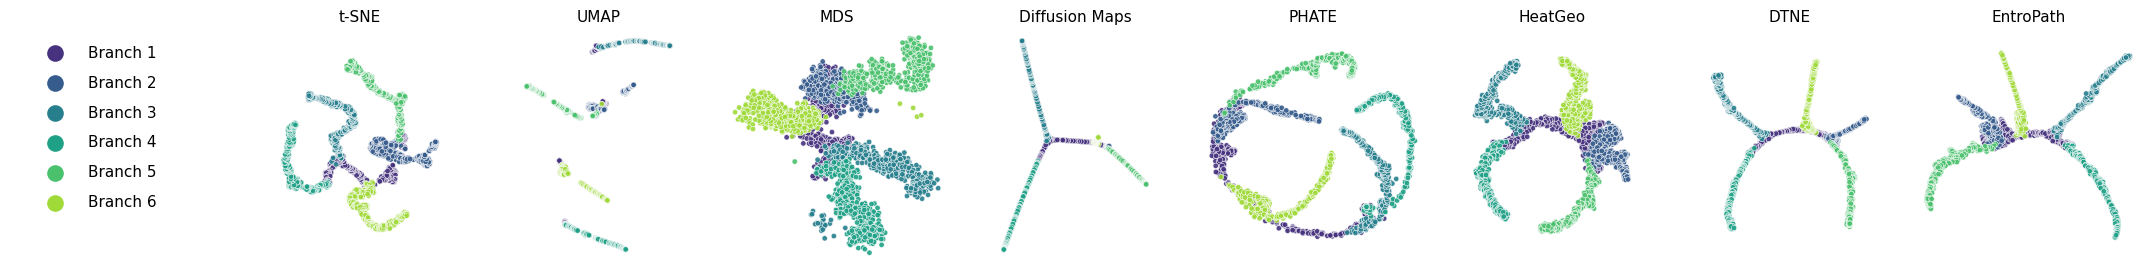

In [13]:
n_panels = 1 + len(PLOT_METHODS)        # legend + method panels

PANEL = 2.4
fig, axes = plt.subplots(1, n_panels,
                         figsize=(PANEL * n_panels, PANEL + 0.4))

palette = sns.color_palette("viridis", n_colors=N_BRANCH)
POINT_KWARGS = dict(s=15, alpha=0.9, linewidths=0.4,
                    edgecolors="white", rasterized=True)

# Legend panel (first)
legend_ax = axes[0]
legend_ax.set_xlim(0, 1); legend_ax.set_ylim(0, 1)
for branch in range(N_BRANCH):
    y_pos = 0.9 - branch * 0.13
    legend_ax.scatter(0.2, y_pos, c=[palette[branch]], s=120, marker="o")
    legend_ax.text(0.35, y_pos, f"Branch {branch + 1}",
                   fontsize=11, verticalalignment="center")
#legend_ax.set_title("Branch legend", fontsize=11, pad=6)
legend_ax.set_xticks([]); legend_ax.set_yticks([])
for spine in legend_ax.spines.values():
    spine.set_visible(False)

# Embedding panels
for ax, name in zip(axes[1:], PLOT_METHODS):
    if name in embeddings_plot:
        emb = embeddings_plot[name]
        colors = [palette[int(l)] for l in labels_plot]
        ax.scatter(emb[:, 0], emb[:, 1], c=colors, **POINT_KWARGS)
        ax.set_aspect("equal", adjustable="datalim")
    ax.set_title(name, fontsize=11, pad=6)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"tree_{TAG}_row.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / f"tree_{TAG}_row.png", dpi=300, bbox_inches="tight")
plt.show()


### Embedding grid (all methods)

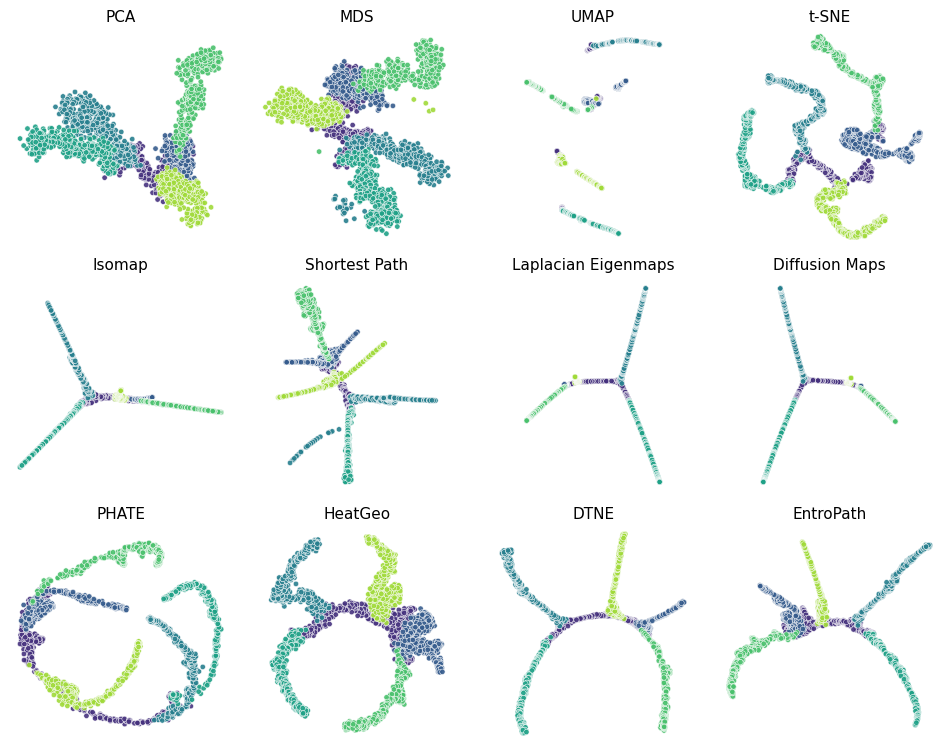

In [14]:
n_cols = 4
n_rows = -(-len(METHODS) // n_cols)

PANEL = 2.4
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(PANEL * n_cols, PANEL * n_rows + 0.4))
axes = np.atleast_1d(axes).flatten()

for ax, name in zip(axes, METHODS):
    if name in embeddings_plot:
        emb = embeddings_plot[name]
        colors = [palette[int(l)] for l in labels_plot]
        ax.scatter(emb[:, 0], emb[:, 1], c=colors, **POINT_KWARGS)
        ax.set_aspect("equal", adjustable="datalim")
    ax.set_title(name, fontsize=11, pad=6)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

for ax in axes[len(METHODS):]:
    ax.set_visible(False)

fig.tight_layout()
plt.savefig(FIGURES_DIR / f"embeddings_grid_tree_{TAG}.pdf",
            bbox_inches="tight")
plt.savefig(FIGURES_DIR / f"embeddings_grid_tree_{TAG}.png",
            dpi=300, bbox_inches="tight")
plt.show()


### Save artifacts

In [15]:
X_plot, X_clean_plot, labels_plot, D_geo_plot = make_data(PLOT_SEED)

save_synthetic_artifacts(
    embeddings_plot, {}, X_clean_plot, X_plot, labels_plot,
    D_geo_plot, level2_results=None,
    config={"plot_seed": PLOT_SEED, "tag": TAG, "n_samples": N_SAMPLES,
            "sigma": SIGMA, "n_branch": N_BRANCH, "branch_length": BRANCH_LENGTH,
            "n_dim": N_DIM, "geodesic_type": GEODESIC_TYPE},
    results_dir=RESULTS_DIR, basename=f"tree_{TAG}",
)

PosixPath('/Users/przemyslawrola/Desktop/EntroPath/results/tree/shortest_path/tree_shortest_path_artifacts.pkl')

### Shepard diagram

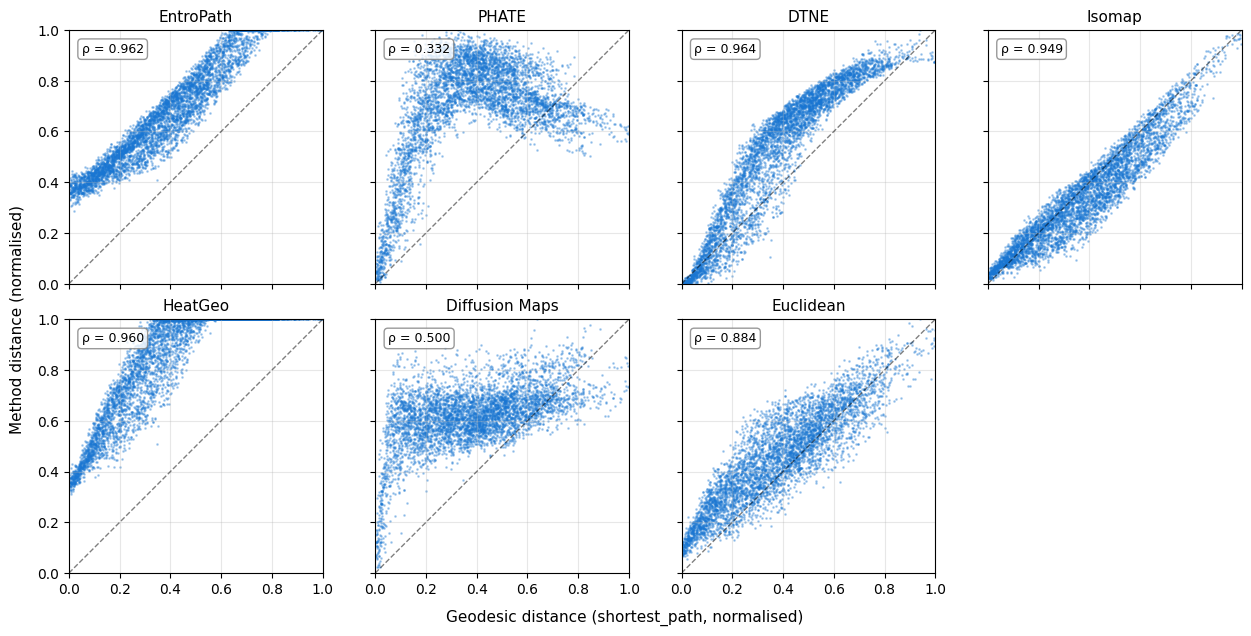

In [16]:
# Use the PLOT_SEED D_geo for Shepard diagram
_, _, _, D_geo_plot = make_data(PLOT_SEED)

PLOT_DIST_METHODS = ["EntroPath", "PHATE", "DTNE", "Isomap",
                     "HeatGeo", "Diffusion Maps", "Euclidean"]

n     = D_geo_plot.shape[0]
upper = np.triu_indices(n, k=1)
rng   = np.random.default_rng(42)
idx   = rng.choice(len(upper[0]), size=min(5000, len(upper[0])), replace=False)
rows_, cols_ = upper[0][idx], upper[1][idx]
geo_vals = D_geo_plot[rows_, cols_]
geo_norm = geo_vals / geo_vals.max()

methods_to_plot = [m for m in PLOT_DIST_METHODS if m in dist_matrices_plot]
n_methods = len(methods_to_plot)
ncols = 4
nrows = -(-n_methods // ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(3.2 * ncols, 3.2 * nrows),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes).flatten()

for ax, name in zip(axes, methods_to_plot):
    D_method    = dist_matrices_plot[name]
    method_vals = D_method[rows_, cols_]
    method_norm = method_vals / method_vals.max()

    ax.scatter(geo_norm, method_norm,
               s=1, alpha=0.3, rasterized=True, color="#1976D2")
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)

    rho, _ = spearmanr(geo_vals, method_vals)
    ax.text(0.05, 0.95, f"ρ = {rho:.3f}",
            transform=ax.transAxes, fontsize=9,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="white",
                      alpha=0.8, edgecolor="gray"))

    ax.set_title(name, fontsize=11)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

for ax in axes[n_methods:]:
    ax.set_visible(False)

fig.supxlabel(f"Geodesic distance ({GEODESIC_TYPE}, normalised)",
              fontsize=11, y=0.02)
fig.supylabel("Method distance (normalised)", fontsize=11, x=0.02)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"tree_{TAG}_shepard.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / f"tree_{TAG}_shepard.png", dpi=300, bbox_inches="tight")
plt.show()


### Box plots — Level 2 (embedding evaluation)

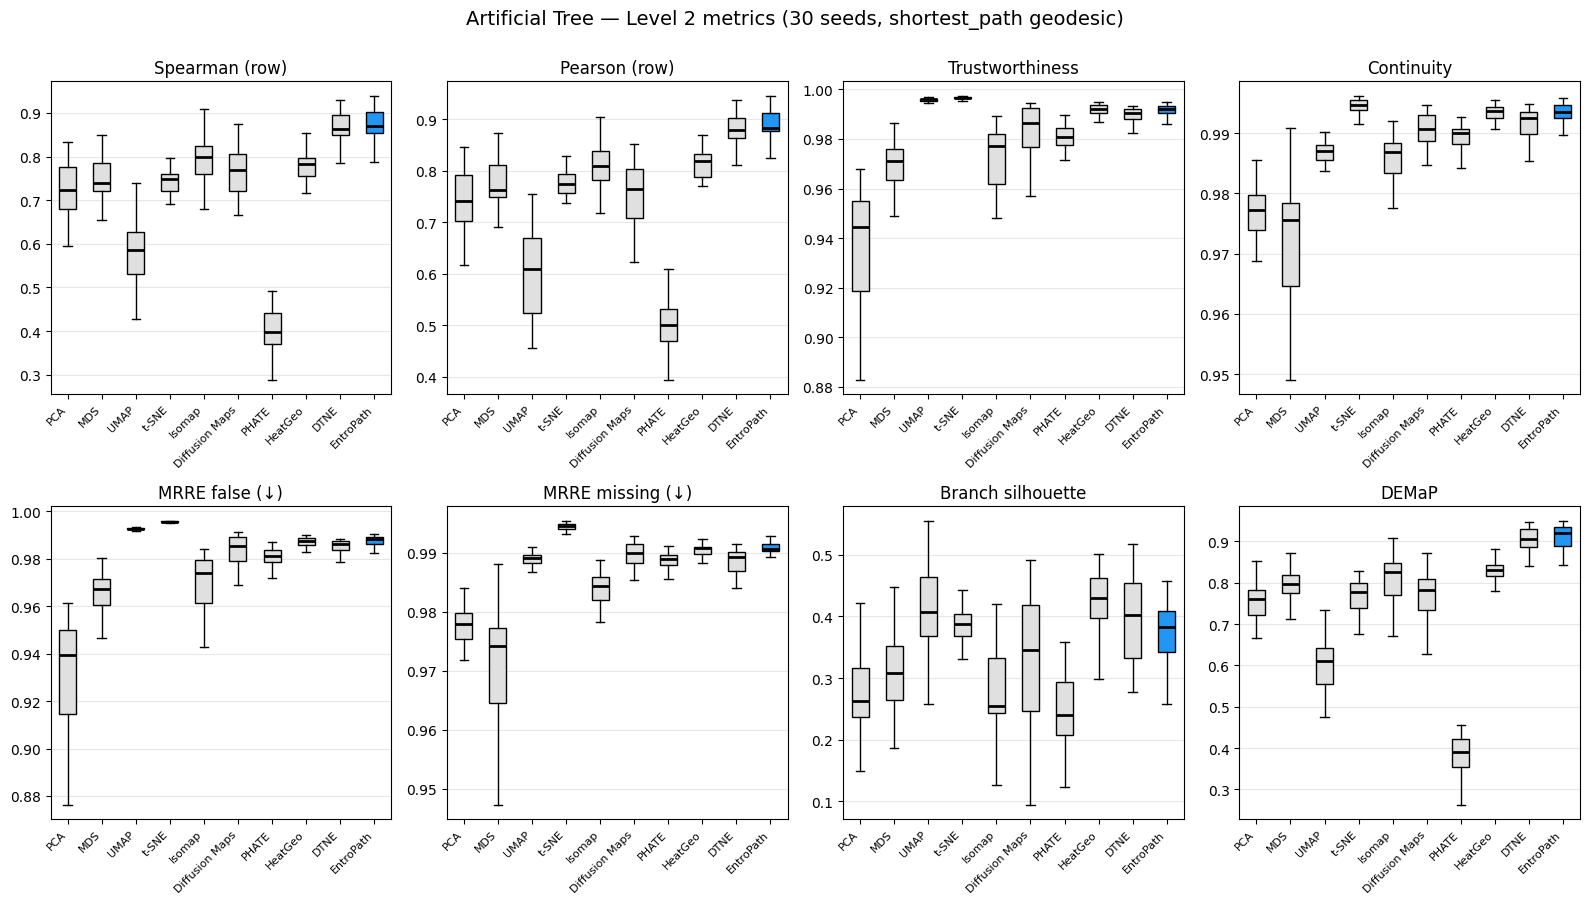

In [17]:
main_metrics = ["spearman_row", "pearson_row", "trust", "continuity",
                "mrre_false", "mrre_missing", "silhouette_branch", "demap"]

BOXPLOT_METHODS = [
    "PCA", "MDS", "UMAP", "t-SNE",
    "Isomap", "Diffusion Maps",
    "PHATE", "HeatGeo", "DTNE", "EntroPath",
]
plot_names = [n for n in BOXPLOT_METHODS
              if n in results_l2 and results_l2[n].get("spearman_row")]

ncols = 4
nrows = -(-len(main_metrics) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4.5 * nrows))
axes = axes.flatten()

for ax, metric in zip(axes, main_metrics):
    data = [results_l2[n][metric] for n in plot_names]
    bp = ax.boxplot(
        data, patch_artist=True, showfliers=False,
        medianprops={"color": "black", "linewidth": 2},
    )
    colors = ["#2196F3" if n == "EntroPath" else "#E0E0E0"
              for n in plot_names]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)

    ax.set_xticklabels(plot_names, rotation=45, ha="right", fontsize=8)
    ax.set_title(TREE_METRIC_INFO[metric], fontsize=12)
    ax.grid(True, axis="y", alpha=0.3)

for ax in axes[len(main_metrics):]:
    ax.set_visible(False)

plt.suptitle(
    f"Artificial Tree — Level 2 metrics "
    f"({N_SEEDS} seeds, {GEODESIC_TYPE} geodesic)",
    fontsize=14, y=1.00,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"tree_{TAG}_boxplots_l2.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / f"tree_{TAG}_boxplots_l2.png",
            dpi=300, bbox_inches="tight")
plt.show()


In [18]:
summary = pd.DataFrame({
    TREE_METRIC_INFO[m]: {n: np.median(results_l2[n][m])
                          for n in BOXPLOT_METHODS
                          if n in results_l2 and results_l2[n].get(m)}
    for m in main_metrics
})
print(f"=== Median summary ({GEODESIC_TYPE} geodesic) ===")
print(summary.round(3))


=== Median summary (shortest_path geodesic) ===
                Spearman (row)  Pearson (row)  Trustworthiness  Continuity  \
PCA                      0.722          0.742            0.944       0.977   
MDS                      0.738          0.762            0.971       0.976   
UMAP                     0.586          0.609            0.996       0.987   
t-SNE                    0.748          0.774            0.997       0.995   
Isomap                   0.799          0.809            0.977       0.987   
Diffusion Maps           0.770          0.765            0.986       0.991   
PHATE                    0.399          0.501            0.981       0.990   
HeatGeo                  0.782          0.820            0.992       0.994   
DTNE                     0.862          0.880            0.990       0.993   
EntroPath                0.870          0.884            0.992       0.993   

                MRRE false (↓)  MRRE missing (↓)  Branch silhouette  DEMaP  
PCA             

### Box plots — Level 1 (distance matrix evaluation)

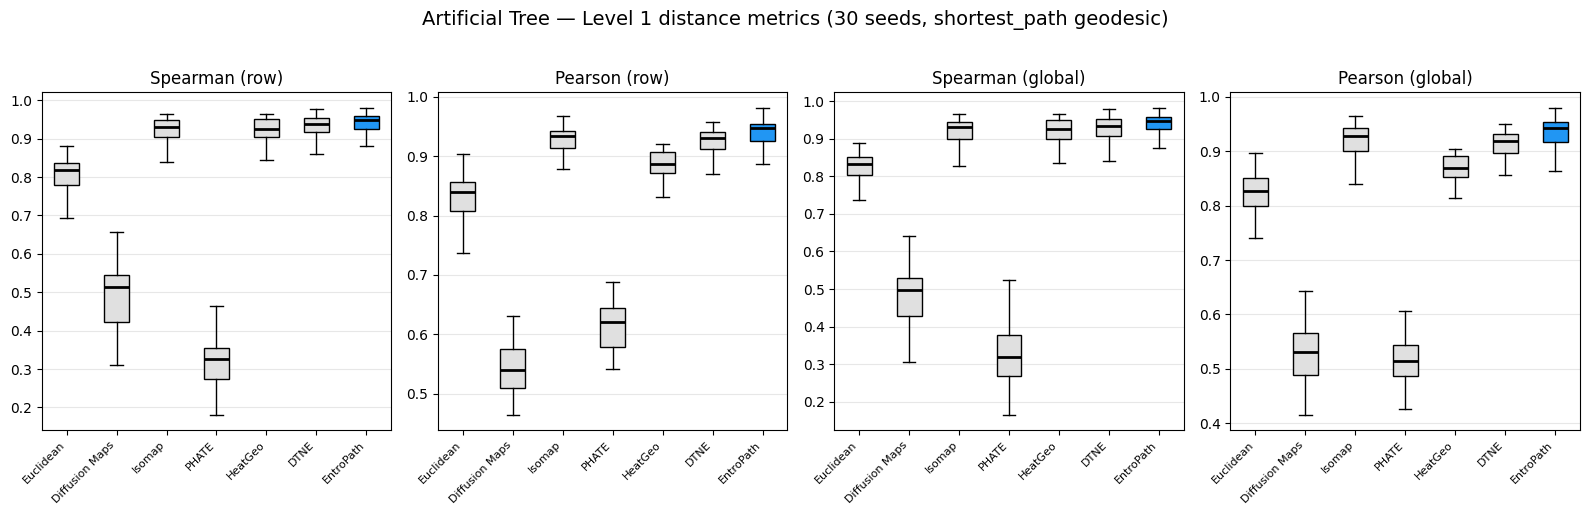

In [19]:
l1_metrics = ["spearman_row", "pearson_row",
              "spearman_global", "pearson_global"]

BOXPLOT_METHODS_L1 = [
    "Euclidean", "Diffusion Maps", "Isomap",
    "PHATE", "HeatGeo", "DTNE", "EntroPath",
]
l1_plot_names = [n for n in BOXPLOT_METHODS_L1
                 if n in results_l1 and results_l1[n].get("spearman_row")]

fig, axes = plt.subplots(1, len(l1_metrics),
                         figsize=(4 * len(l1_metrics), 5))

for ax, metric in zip(axes, l1_metrics):
    data = [results_l1[n][metric] for n in l1_plot_names]
    bp = ax.boxplot(
        data, patch_artist=True, showfliers=False,
        medianprops={"color": "black", "linewidth": 2},
    )
    colors = ["#2196F3" if n == "EntroPath" else "#E0E0E0"
              for n in l1_plot_names]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)

    ax.set_xticklabels(l1_plot_names, rotation=45, ha="right", fontsize=8)
    ax.set_title(TREE_METRIC_INFO[metric], fontsize=12)
    ax.grid(True, axis="y", alpha=0.3)

plt.suptitle(
    f"Artificial Tree — Level 1 distance metrics "
    f"({N_SEEDS} seeds, {GEODESIC_TYPE} geodesic)",
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"tree_{TAG}_boxplots_l1.pdf",
            bbox_inches="tight")
plt.savefig(FIGURES_DIR / f"tree_{TAG}_boxplots_l1.png",
            dpi=300, bbox_inches="tight")
plt.show()


### Stability across seeds (geodesic-family methods)

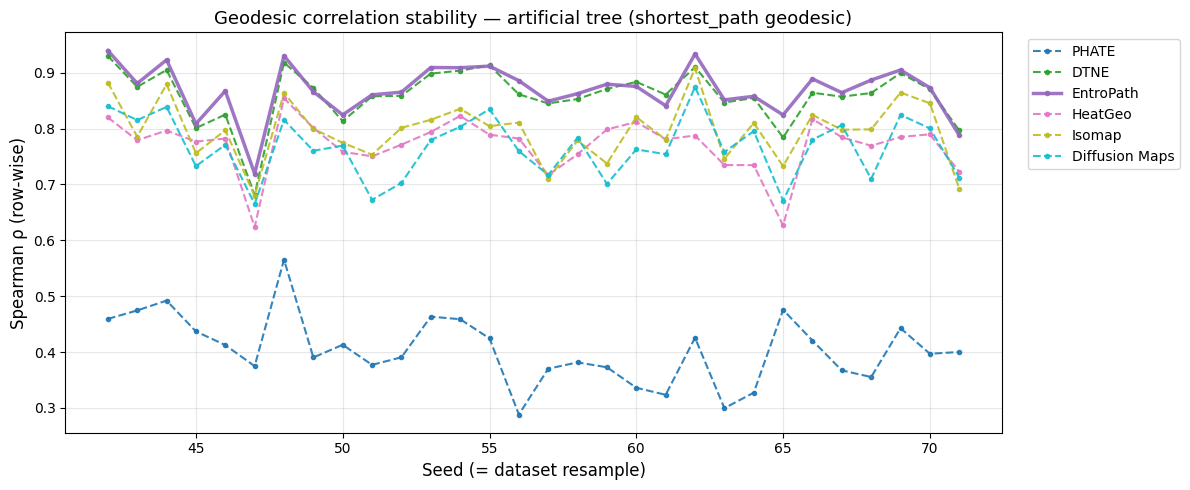

In [20]:
stability_methods = ["PHATE", "DTNE", "EntroPath", "HeatGeo",
                     "Isomap", "Diffusion Maps"]
plot_methods_names = [n for n in stability_methods
                      if n in results_l2 and results_l2[n].get("spearman_row")]

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(plot_methods_names)))

for name, color in zip(plot_methods_names, colors):
    vals = results_l2[name]["spearman_row"]
    ls   = "-" if name == "EntroPath" else "--"
    lw   = 2.5 if name == "EntroPath" else 1.5
    ax.plot(
        SEEDS[:len(vals)], vals,
        marker="o", markersize=3,
        color=color, label=name,
        linewidth=lw, linestyle=ls, alpha=0.9,
    )

ax.set_xlabel("Seed (= dataset resample)", fontsize=12)
ax.set_ylabel("Spearman ρ (row-wise)", fontsize=12)
ax.set_title(
    f"Geodesic correlation stability — artificial tree "
    f"({GEODESIC_TYPE} geodesic)",
    fontsize=13,
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"tree_{TAG}_stability.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / f"tree_{TAG}_stability.png",
            dpi=300, bbox_inches="tight")
plt.show()
